In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
train_data = datasets.FashionMNIST(root='./data', download=True, train=True, transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root='./data', download=True, train=False, transform=transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.93MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 171kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.18MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.4MB/s]


In [3]:
train_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [4]:
len(train_data.classes)

10

In [5]:
train = DataLoader(train_data, batch_size=32, shuffle=True)
test = DataLoader(test_data, batch_size=32)

In [6]:
# Лучшие параметры: {'lr': 0.0008452743777365214, 'batch_size': 64}

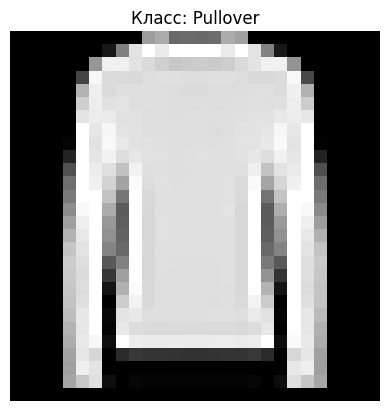

In [7]:
image, label = next(iter(train))
plt.imshow(image[0].squeeze(), cmap='gray')
plt.title(f'Класс: {train_data.classes[label[0]]}')
plt.axis('off')
plt.savefig('image_1')
plt.show()

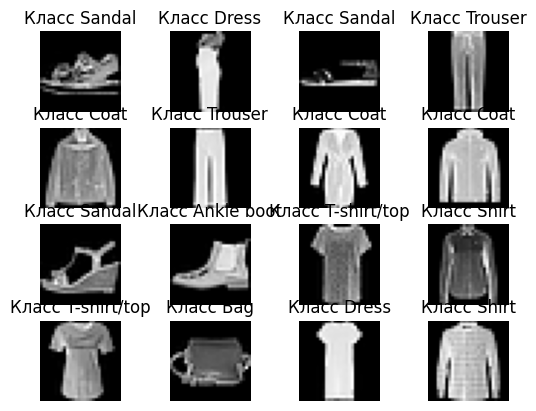

In [8]:
image, label = next(iter(train))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image[i].squeeze(), cmap='gray')
    plt.title(f'Класс {train_data.classes[label[i]]}')
    plt.axis('off')
plt.savefig('image_set')
plt.show()

In [9]:
class CheckImage(nn.Module):
    def __init__(self):
        super().__init__()
        self.first = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.second = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, image):
        image = self.first(image)
        image = self.second(image)
        return image

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [11]:
device

device(type='cuda')

In [12]:
model_CheckImage = CheckImage().to(device)

In [13]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_CheckImage.parameters(), lr=0.001)

In [15]:
for epoch in range(20):
    model_CheckImage.train()
    total_loss = 0
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_CheckImage(x_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f'Эпоха {epoch +1} -- Потери: {round(total_loss, 2)}')

Эпоха 1 -- Потери: 686.45
Эпоха 2 -- Потери: 581.21
Эпоха 3 -- Потери: 514.49
Эпоха 4 -- Потери: 458.17
Эпоха 5 -- Потери: 421.96
Эпоха 6 -- Потери: 388.16
Эпоха 7 -- Потери: 356.53
Эпоха 8 -- Потери: 331.68
Эпоха 9 -- Потери: 306.87
Эпоха 10 -- Потери: 285.11
Эпоха 11 -- Потери: 270.01
Эпоха 12 -- Потери: 256.23
Эпоха 13 -- Потери: 240.83
Эпоха 14 -- Потери: 225.03
Эпоха 15 -- Потери: 220.98
Эпоха 16 -- Потери: 205.8
Эпоха 17 -- Потери: 192.17
Эпоха 18 -- Потери: 187.96
Эпоха 19 -- Потери: 180.46
Эпоха 20 -- Потери: 174.07


In [16]:
model_CheckImage.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        y_pred = model_CheckImage(x_batch)
        prediction = torch.argmax(y_pred, dim=1)
        total += y_batch.size(0)
        correct += (prediction == y_batch).sum().item()

accuracy = correct * 100 / total
print(f'Точеность модели на тестовых данных: {round(accuracy, 2)}%')

Точеность модели на тестовых данных: 91.58%


In [17]:
def get_accuracy(data_loader):
    model_CheckImage.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            y_pred = model_CheckImage(x_batch)
            prediction = torch.argmax(y_pred, dim=1)
            total += y_batch.size(0)
            correct += (prediction == y_batch).sum().item()
    return round(correct * 100 / total, 2)

print(f'train score: {get_accuracy(train)}%')
print(f'test score: {get_accuracy(test)}%')

train score: 98.73%
test score: 91.58%


In [18]:
torch.save(model_CheckImage.state_dict(), 'model_CheckImage_MnistFashion.pth')

In [19]:
# !pip install optuna

In [20]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
# import optuna

# train_data = datasets.FashionMNIST(root='./data', download=True, train=True, transform=transforms.ToTensor())
# test_data = datasets.FashionMNIST(root='./data', download=True, train=False, transform=transforms.ToTensor())

# class CheckImage(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.first = nn.Sequential(
#         nn.Conv2d(1, 64, kernel_size=3, padding=1),
#         nn.ReLU(),
#         nn.MaxPool2d(2)
#         )
#         self.second = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(64 * 14 * 14, 128),
#         nn.ReLU(),
#         nn.Linear(128, 10)
#         )
#     def forward(self, image):
#         image = self.first(image)
#         image = self.second(image)
#         return image

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# def objective(trial):
#     # Подбираемые гиперпараметры
#     lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)
#     batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])

#     # DataLoader с текущим batch_size
#     train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
#     test_loader = DataLoader(test_data, batch_size=batch_size)

#     # Модель и оптимизатор
#     model = CheckImage().to(device)
#     optimizer = optim.Adam(model.parameters(), lr=lr)
#     loss_fn = nn.CrossEntropyLoss()

#     # Обучение (10 эпох для быстрого подбора)
#     for epoch in range(10):
#         model.train()
#         for x_batch, y_batch in train_loader:
#             x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#             y_pred = model(x_batch)
#             loss = loss_fn(y_pred, y_batch)

#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#     # Оценка точности
#     model.eval()
#     correct = 0
#     total = 0
#     with torch.no_grad():
#         for x_batch, y_batch in test_loader:
#             x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#             y_pred = model(x_batch)
#             prediction = torch.argmax(y_pred, dim=1)
#             total += y_batch.size(0)
#             correct += (prediction == y_batch).sum().item()

#     accuracy = correct / total
#     return accuracy

# # Запуск Optuna
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=20)

# print('Лучшие параметры:', study.best_params)
# print('Лучшая точность:', round(study.best_value * 100, 2), '%')

# # Обучение с лучшими параметрами
# best_lr = study.best_params['lr']
# best_batch_size = study.best_params['batch_size']

# train_loader = DataLoader(train_data, batch_size=best_batch_size, shuffle=True)
# test_loader = DataLoader(test_data, batch_size=best_batch_size)

# model = CheckImage().to(device)
# optimizer = optim.Adam(model.parameters(), lr=best_lr)
# loss_fn = nn.CrossEntropyLoss()

# for epoch in range(100):
#     model.train()
#     total_loss = 0
#     for x_batch, y_batch in train_loader:
#         x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#         y_pred = model(x_batch)
#         loss = loss_fn(y_pred, y_batch)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#     print(f'Эпоха {epoch + 1} -- Потери: {round(total_loss, 2)}')

# model.eval()
# correct = 0
# total = 0
# with torch.no_grad():
#     for x_batch, y_batch in test_loader:
#         x_batch, y_batch = x_batch.to(device), y_batch.to(device)
#         y_pred = model(x_batch)
#         prediction = torch.argmax(y_pred, dim=1)
#         total += y_batch.size(0)
#         correct += (prediction == y_batch).sum().item()

# accuracy = correct * 100 / total
# print(f'Точность модели на тестовых данных: {round(accuracy, 2)}%')

# torch.save(model.state_dict(), 'fashion_mnist_optimized.pth')